# PCA BrainODE vs PCA Cocycle/Consistency v4

This notebook is a **load-only report**. It reads a prepared CSV/JSON cache and never loads checkpoints, runs CUDA inference, decodes PCA predictions, or computes hotspot maps. Test results are the primary model comparison; the all-data views are descriptive.

## Build the cache before opening this report

Run the standalone preparation script once. The full group-map command uses every available forward pair.

```bash
V4=examples/ADNI_1_L_No_MCI_large_strict_left/task3_longitudinal_prediction/pca150_v1_anchored_ad_speed_cocycle_qc_v4

/home/jakaria/anaconda3/envs/inr_sdf/bin/python \
  $V4/scripts/build_brainode_vs_cocycle_notebook_cache.py \
  --config $V4/configs/v1_anchored_ad_speed_primary.json \
  --metadata-dir $V4/metadata \
  --run-name v1_anchor_ad_speed_seed42 \
  --checkpoint best_feasible_volume \
  --splits train val test \
  --device cuda:0 \
  --group-map-max-pairs-per-diagnosis 0 \
  --output-dir $V4/analysis/notebook_brainode_vs_cocycle_all_data/prepared_cache_v1
```

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except Exception:
    go = None
    make_subplots = None

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() or (candidate / 'deep_sdf').is_dir():
            return candidate
    raise RuntimeError(f'Could not find repository root from {start}')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
EXP_DIR = REPO_ROOT / 'examples/ADNI_1_L_No_MCI_large_strict_left/task3_longitudinal_prediction/pca150_v1_anchored_ad_speed_cocycle_qc_v4'
CACHE_DIR = EXP_DIR / 'analysis/notebook_brainode_vs_cocycle_all_data/prepared_cache_v1'
MANIFEST_PATH = CACHE_DIR / 'manifest.json'

if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(f'Prepared cache is missing: {MANIFEST_PATH}\nRun the command in the previous cell.')
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
if manifest.get('status') != 'complete':
    raise RuntimeError(f"Cache status is {manifest.get('status')!r}, not 'complete'. Rerun the cache builder.")
missing = [CACHE_DIR / item for item in manifest.get('required_files', []) if not (CACHE_DIR / item).is_file()]
if missing:
    raise FileNotFoundError('Prepared cache is incomplete:\n' + '\n'.join(str(path) for path in missing))

MODEL_COLORS = {'brainode': '#6C757D', 'v4': '#0072B2', 'GT': '#111111'}
MODEL_LABELS = {'brainode': 'PCA BrainODE', 'v4': 'PCA Cocycle/Consistency v4'}
METRIC_SPECS = {
    'endpoint_vertex_mae': ('Vertex MAE', True),
    'endpoint_pca_mse': ('PCA MSE', True),
    'endpoint_vertex_hd95': ('Vertex HD95', True),
    'volume_relative_error': ('Volume relative error', True),
    'log_volume_rate_abs_error': ('Log-volume-rate error', True),
    'local_normal_rate_mae': ('Local normal-rate MAE', True),
    'local_normal_rate_pearson': ('Local normal-rate Pearson', False),
    'local_normal_top_change_dice': ('Top-change Dice', False),
}

if sns is not None:
    sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'figure.dpi': 125, 'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
    'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
pd.set_option('display.max_columns', 40)
print('cache:', CACHE_DIR)
print('completed:', manifest.get('completed_at'))

cache: /home/jakaria/INR/Deep3DComp/examples/ADNI_1_L_No_MCI_large_strict_left/task3_longitudinal_prediction/pca150_v1_anchored_ad_speed_cocycle_qc_v4/analysis/notebook_brainode_vs_cocycle_all_data/prepared_cache_v1
completed: 2026-08-05T05:28:23.403730+00:00


In [2]:
TABLE_FILES = {
    'counts': 'cohort_counts.csv',
    'metrics': 'metric_summary.csv',
    'paired': 'paired_metric_comparison.csv',
    'bootstrap': 'paired_bootstrap_ci.csv',
    'gaps': 'gap_summary.csv',
    'subject_trends': 'subject_volume_trends.csv',
    'trend_summary': 'cohort_volume_trend_summary.csv',
    'trajectories': 'selected_volume_trajectories.csv',
    'counterfactual': 'counterfactual_trajectories.csv',
    'selected_mesh_metrics': 'selected_mesh_metrics.csv',
    'group_hotspot_metrics': 'group_hotspot_metrics.csv',
}
tables = {name: pd.read_csv(CACHE_DIR / 'tables' / filename) for name, filename in TABLE_FILES.items()}
selected_examples = json.loads((CACHE_DIR / 'selected_examples.json').read_text(encoding='utf-8'))
display(tables['counts'].sort_values(['split', 'diagnosis', 'model']))
display(pd.DataFrame(selected_examples).T)

,split,diagnosis,model,model_label,pairs,subjects
0,all,AD,brainode,PCA BrainODE,730,205
1,all,AD,v4,PCA Cocycle/Consistency v4,730,205
2,all,CN,brainode,PCA BrainODE,3955,318
3,all,CN,v4,PCA Cocycle/Consistency v4,3955,318
4,test,AD,brainode,PCA BrainODE,75,21
5,test,AD,v4,PCA Cocycle/Consistency v4,75,21
6,test,CN,brainode,PCA BrainODE,408,29
7,test,CN,v4,PCA Cocycle/Consistency v4,408,29
8,train,AD,brainode,PCA BrainODE,576,160
9,train,AD,v4,PCA Cocycle/Consistency v4,576,160


,diagnosis,future_visits,maximum_followup_years,selection_rule,split,subject_id
AD,AD,3,2.140999,"most future visits, then longest follow-up, th...",test,1339
CN,CN,9,10.195763,"most future visits, then longest follow-up, th...",test,113


## Primary registered-mesh comparison

Every comparison is paired on the same source/target visit. The arrow beside each metric states the preferred direction.

In [3]:
primary = tables['metrics'][tables['metrics']['split'] == 'test'].copy()
primary['preferred_direction'] = primary['direction_symbol'] + np.where(primary['direction'] == 'lower', ' lower is better', ' higher is better')
columns = [
    'diagnosis', 'metric_label', 'preferred_direction', 'pairs', 'brainode_mean',
    'cocycle_mean', 'delta_favoring_cocycle_mean', 'cocycle_win_fraction', 'better_model',
]
primary_display = primary[columns].sort_values(['diagnosis', 'metric_label']).copy()
for column in ('brainode_mean', 'cocycle_mean', 'delta_favoring_cocycle_mean'):
    primary_display[column] = primary_display[column].round(6)
primary_display['cocycle_win_fraction'] = (100.0 * primary_display['cocycle_win_fraction']).round(1).astype(str) + '%'
display(primary_display)

,diagnosis,metric_label,preferred_direction,pairs,brainode_mean,cocycle_mean,delta_favoring_cocycle_mean,cocycle_win_fraction,better_model
19,AD,Local normal-rate MAE,↓ lower is better,75,0.024330,0.023275,0.001055,86.7%,PCA Cocycle/Consistency v4
20,AD,Local normal-rate Pearson,↑ higher is better,75,0.106389,0.368698,0.262309,89.3%,PCA Cocycle/Consistency v4
22,AD,Log-volume-rate error,↓ lower is better,75,0.056251,0.053527,0.002724,58.7%,PCA Cocycle/Consistency v4
16,AD,PCA MSE,↓ lower is better,75,0.022628,0.020954,0.001674,89.3%,PCA Cocycle/Consistency v4
21,AD,Top-change Dice,↑ higher is better,75,0.267150,0.330008,0.062857,74.7%,PCA Cocycle/Consistency v4
17,AD,Vertex HD95,↓ lower is better,75,0.066652,0.063259,0.003394,78.7%,PCA Cocycle/Consistency v4
18,AD,Vertex MAE,↓ lower is better,75,0.015080,0.014479,0.000600,84.0%,PCA Cocycle/Consistency v4
23,AD,Volume relative error,↓ lower is better,75,0.049357,0.042959,0.006398,58.7%,PCA Cocycle/Consistency v4
27,CN,Local normal-rate MAE,↓ lower is better,408,0.009412,0.009137,0.000275,78.9%,PCA Cocycle/Consistency v4
28,CN,Local normal-rate Pearson,↑ higher is better,408,0.171263,0.370246,0.198983,85.3%,PCA Cocycle/Consistency v4


In [4]:
def plot_raw_metric(metric: str, split: str = 'test') -> None:
    label, lower_is_better = METRIC_SPECS[metric]
    data = tables['metrics'][(tables['metrics']['split'] == split) & (tables['metrics']['metric'] == metric)].copy()
    diagnoses = [item for item in ('CN', 'AD') if item in set(data['diagnosis'])]
    x = np.arange(len(diagnoses), dtype=float)
    width = 0.34
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    for offset, (column, model, label_model) in enumerate([
        ('brainode_mean', 'brainode', MODEL_LABELS['brainode']),
        ('cocycle_mean', 'v4', MODEL_LABELS['v4']),
    ]):
        values = [float(data.loc[data['diagnosis'] == diagnosis, column].iloc[0]) for diagnosis in diagnoses]
        ax.bar(x + (offset - 0.5) * width, values, width=width, color=MODEL_COLORS[model], label=label_model)
    arrow = '↓' if lower_is_better else '↑'
    phrase = 'lower is better' if lower_is_better else 'higher is better'
    ax.set_title(f'{split.capitalize()} — {label}\n{arrow} {phrase}', pad=12)
    ax.set_ylabel(label)
    ax.set_xticks(x, diagnoses)
    if metric in {'local_normal_top_change_dice', 'local_normal_rate_pearson'}:
        low = -1.0 if metric.endswith('pearson') else 0.0
        ax.set_ylim(low, 1.0)
    ax.legend(frameon=False, loc='best')
    ax.grid(axis='x', visible=False)
    plt.show()

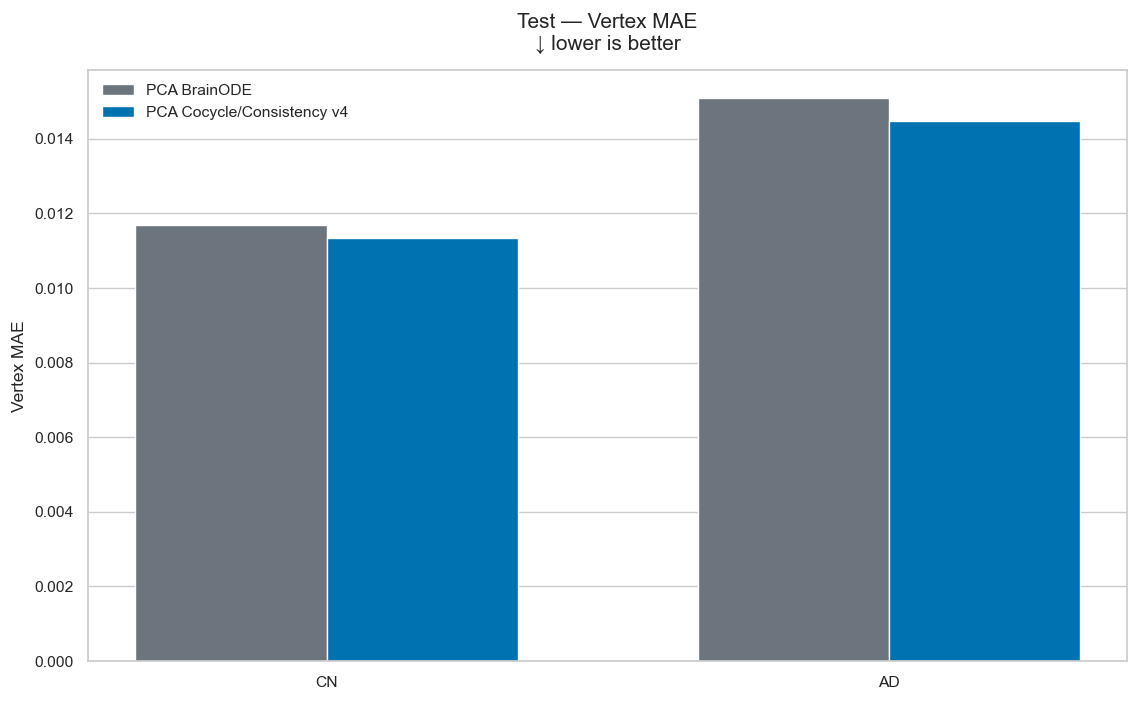

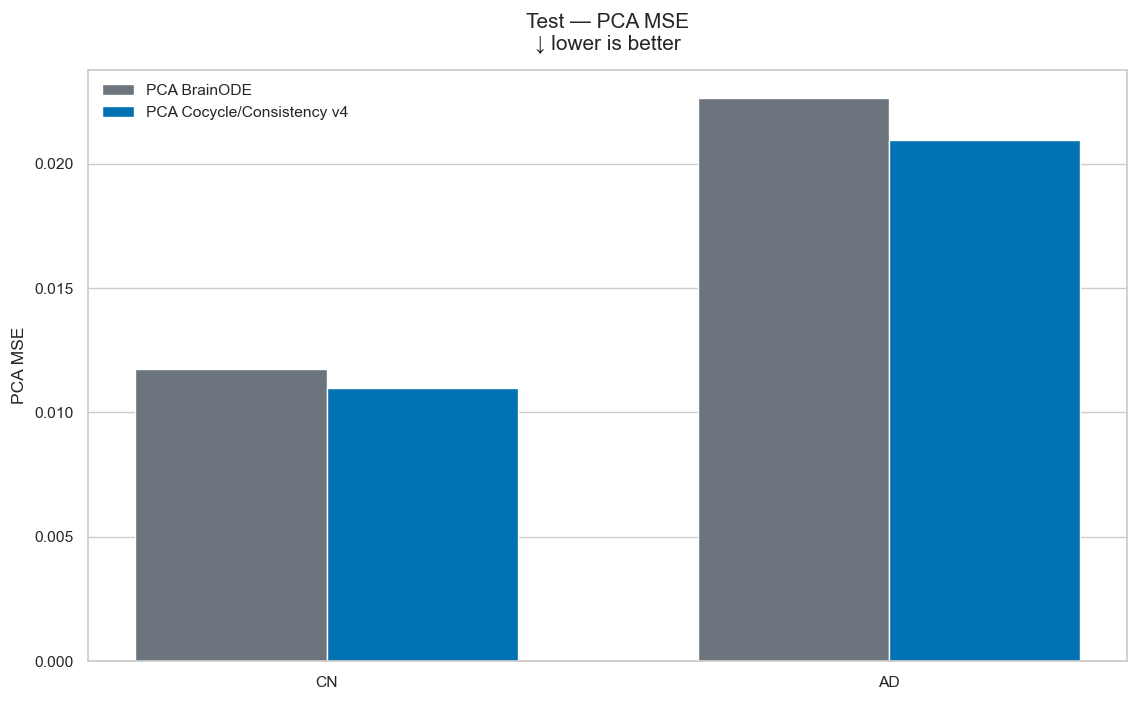

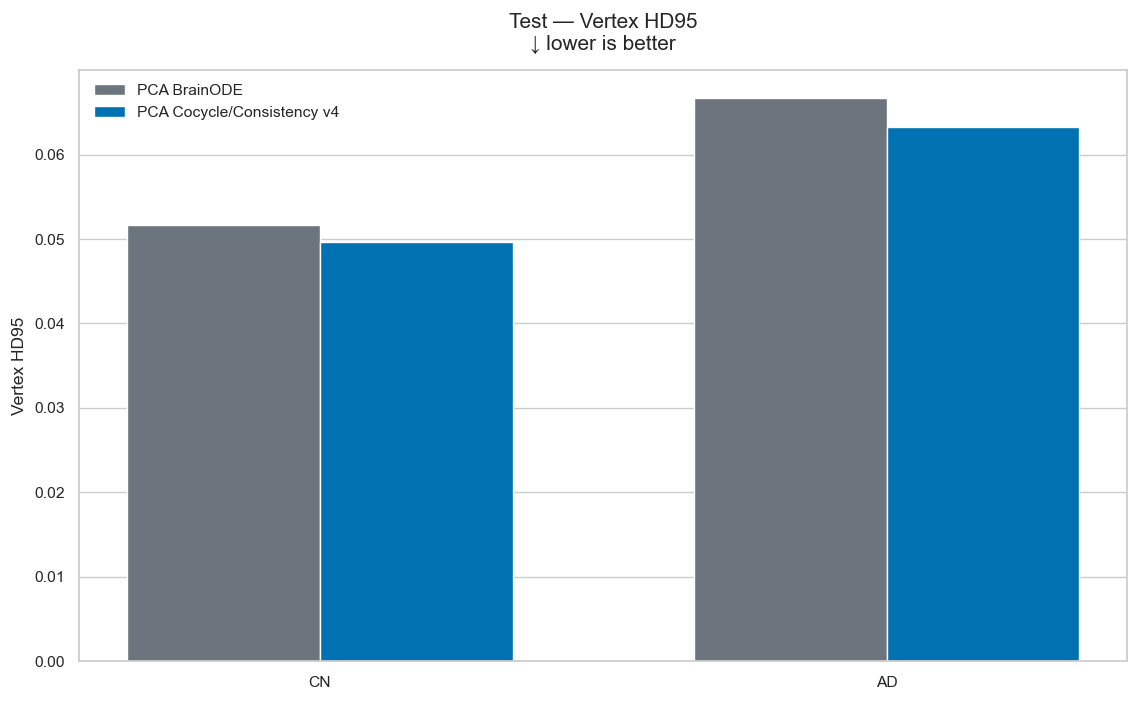

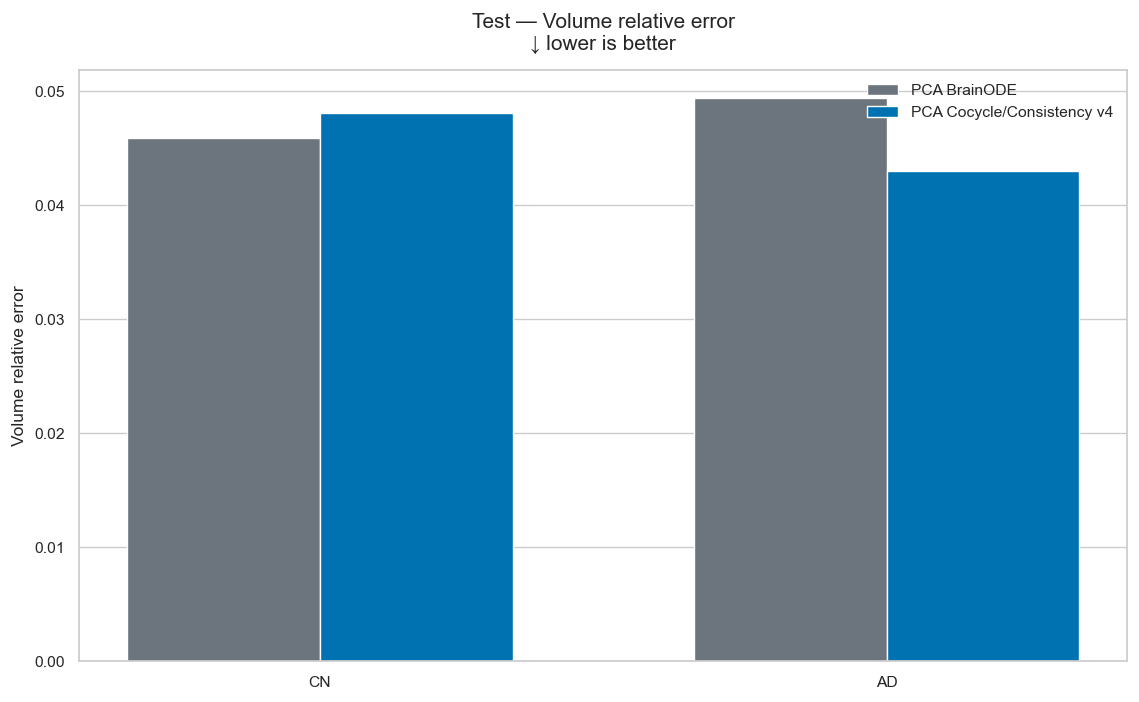

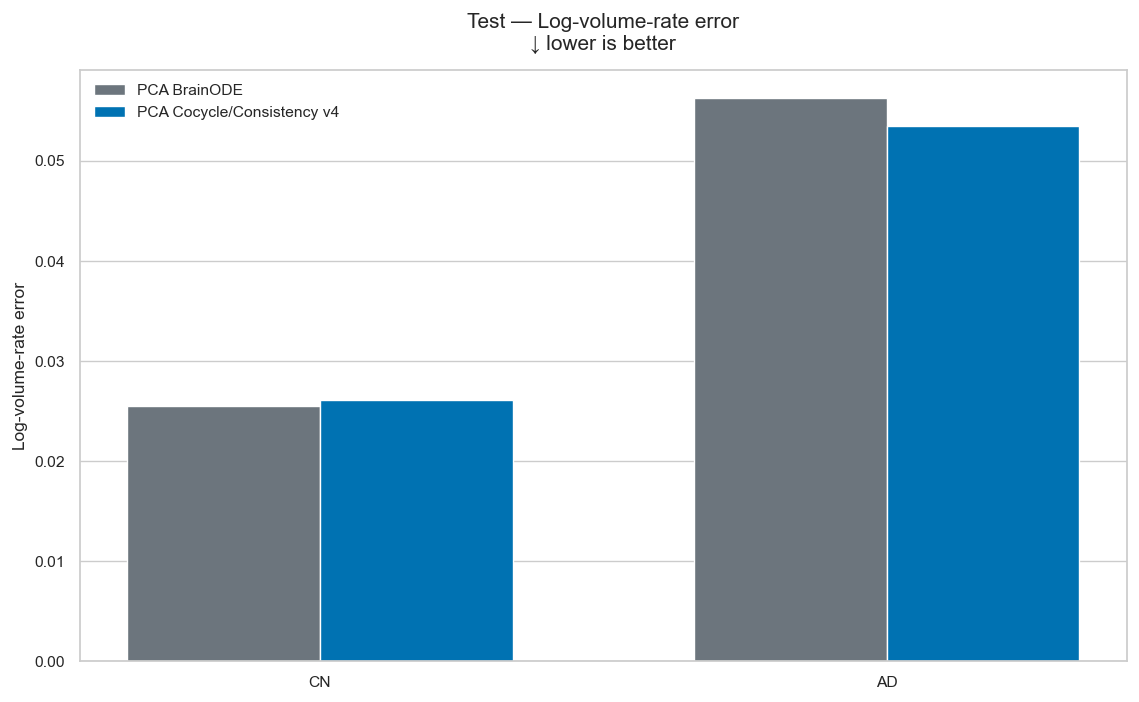

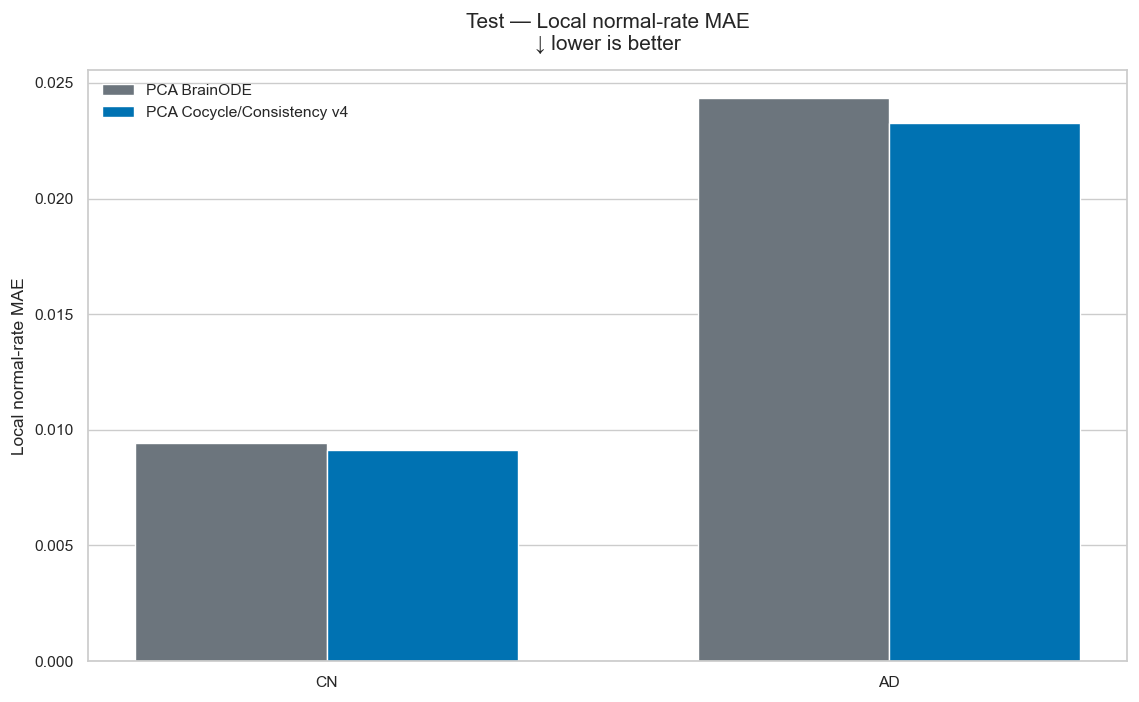

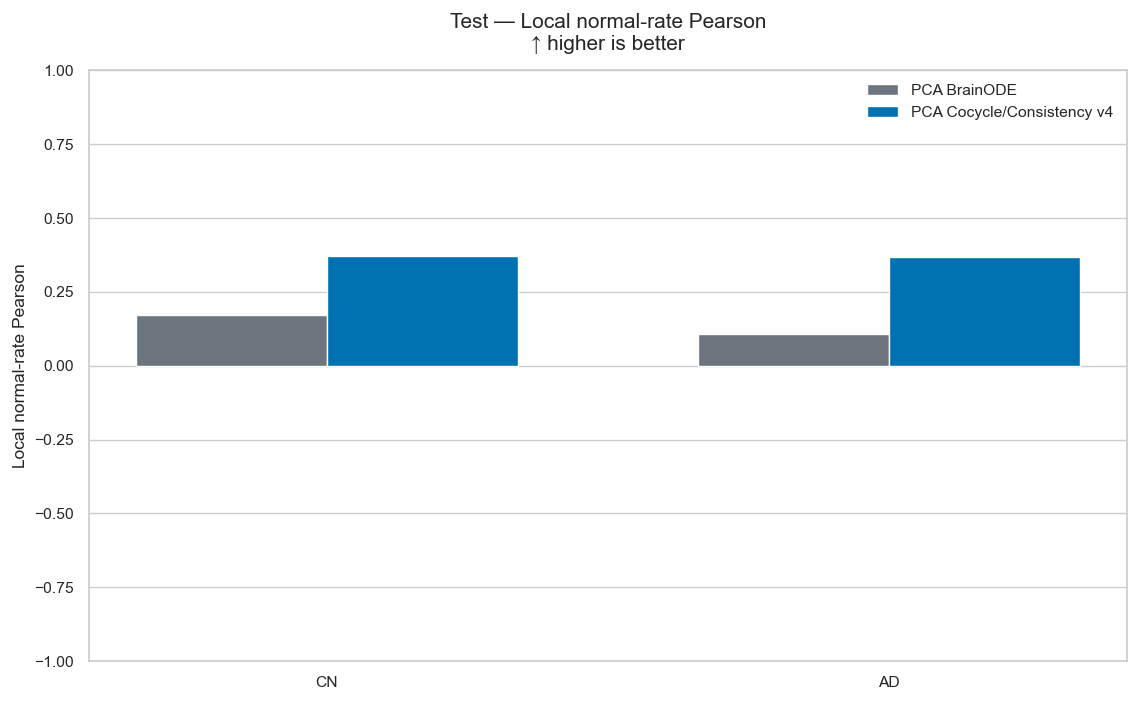

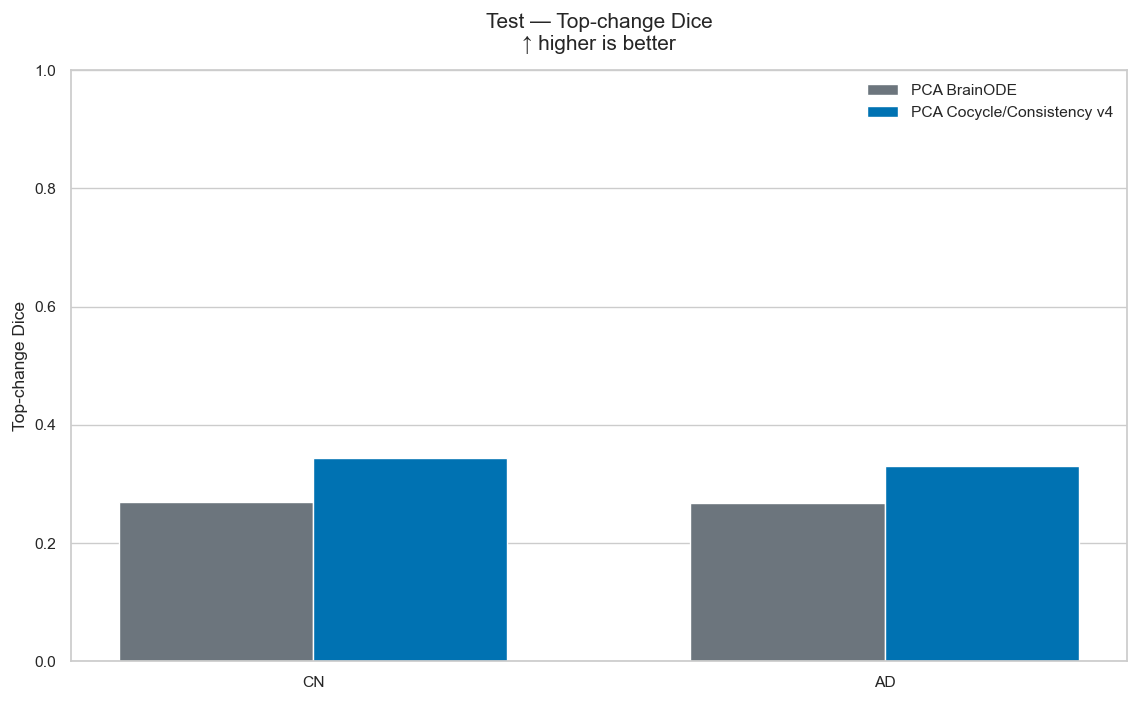

In [5]:
# Each metric receives its own figure and scale.
for metric_name in METRIC_SPECS:
    plot_raw_metric(metric_name, split='test')

## Improvement and uncertainty

All improvement plots use the same sign convention: **positive means cocycle is better**. Error metrics use relative percent improvement. Dice and Pearson use absolute change because relative percentages are unstable near zero.

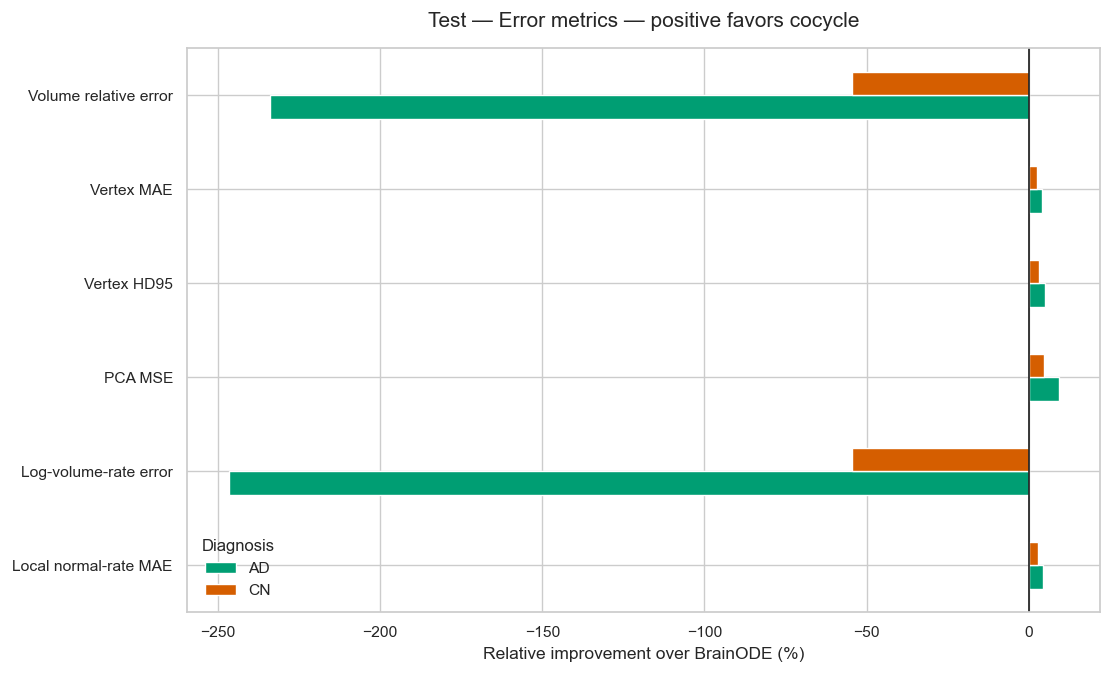

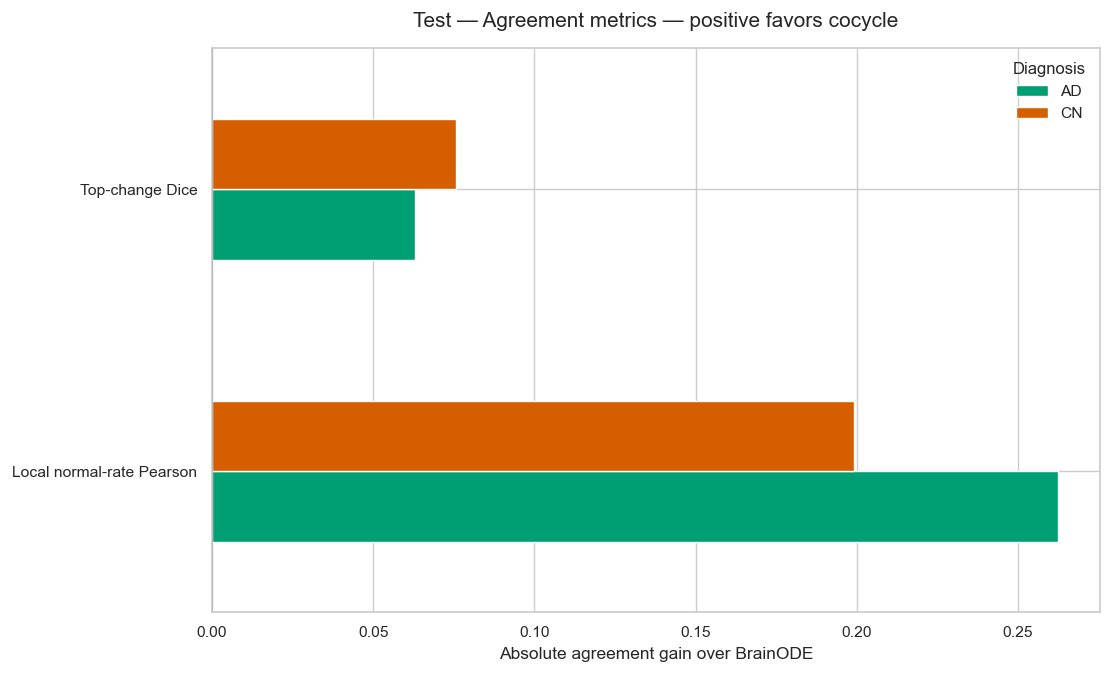

In [6]:
def plot_improvement_summary(direction: str, split: str = 'test') -> None:
    data = tables['metrics'][(tables['metrics']['split'] == split) & (tables['metrics']['direction'] == direction)].copy()
    value_column = 'relative_gain_percent' if direction == 'lower' else 'delta_favoring_cocycle_mean'
    xlabel = 'Relative improvement over BrainODE (%)' if direction == 'lower' else 'Absolute agreement gain over BrainODE'
    title = 'Error metrics — positive favors cocycle' if direction == 'lower' else 'Agreement metrics — positive favors cocycle'
    pivot = data.pivot(index='metric_label', columns='diagnosis', values=value_column)
    ax = pivot.plot(kind='barh', figsize=(9, 5.5), color=['#009E73', '#D55E00'])
    ax.axvline(0.0, color='#222222', linewidth=1)
    ax.set_title(f'{split.capitalize()} — {title}', pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.legend(title='Diagnosis', frameon=False)
    plt.tight_layout()
    plt.show()

plot_improvement_summary('lower', 'test')
plot_improvement_summary('higher', 'test')

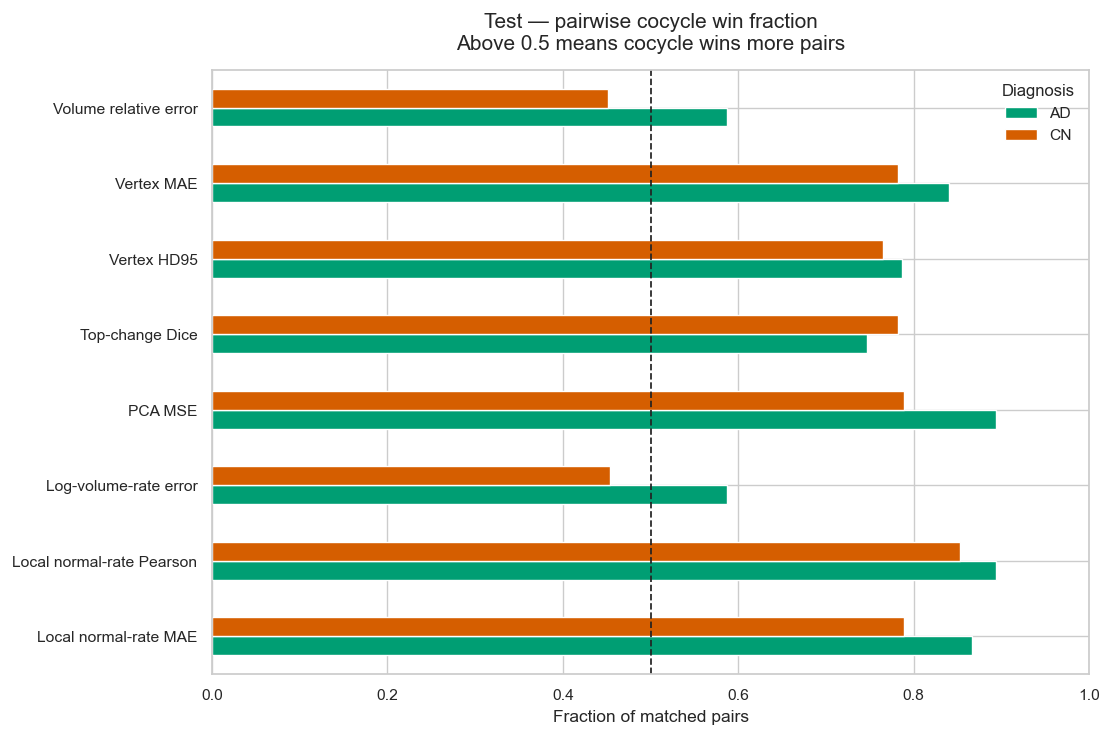

,split,diagnosis,metric,metric_label,direction,subjects,replicates,delta_favoring_cocycle_mean,ci_low,ci_high,probability_cocycle_better
16,test,AD,endpoint_pca_mse,PCA MSE,lower,21,10000,0.001587,0.001015,0.002194,1.0000
17,test,AD,endpoint_vertex_hd95,Vertex HD95,lower,21,10000,0.003039,0.001517,0.004573,1.0000
18,test,AD,endpoint_vertex_mae,Vertex MAE,lower,21,10000,0.000596,0.000375,0.000814,1.0000
19,test,AD,local_normal_rate_mae,Local normal-rate MAE,lower,21,10000,0.001032,0.000620,0.001445,1.0000
20,test,AD,local_normal_rate_pearson,Local normal-rate Pearson,higher,21,10000,0.285977,0.219050,0.361030,1.0000
21,test,AD,local_normal_top_change_dice,Top-change Dice,higher,21,10000,0.069611,0.034949,0.103283,0.9999
22,test,AD,log_volume_rate_abs_error,Log-volume-rate error,lower,21,10000,0.004457,-0.008646,0.016363,0.7565
23,test,AD,volume_relative_error,Volume relative error,lower,21,10000,0.011170,-0.002969,0.025707,0.9375
24,test,CN,endpoint_pca_mse,PCA MSE,lower,29,10000,0.000808,0.000465,0.001224,1.0000
25,test,CN,endpoint_vertex_hd95,Vertex HD95,lower,29,10000,0.001958,0.001175,0.002844,1.0000


In [7]:
test_wins = tables['metrics'][tables['metrics']['split'] == 'test'].pivot(
    index='metric_label', columns='diagnosis', values='cocycle_win_fraction'
)
ax = test_wins.plot(kind='barh', figsize=(9, 6), color=['#009E73', '#D55E00'])
ax.axvline(0.5, color='#222222', linewidth=1, linestyle='--')
ax.set_xlim(0.0, 1.0)
ax.set_title('Test — pairwise cocycle win fraction\nAbove 0.5 means cocycle wins more pairs', pad=12)
ax.set_xlabel('Fraction of matched pairs')
ax.set_ylabel('')
ax.legend(title='Diagnosis', frameon=False)
plt.tight_layout()
plt.show()
display(tables['bootstrap'][tables['bootstrap']['split'] == 'test'].sort_values(['diagnosis', 'metric']))

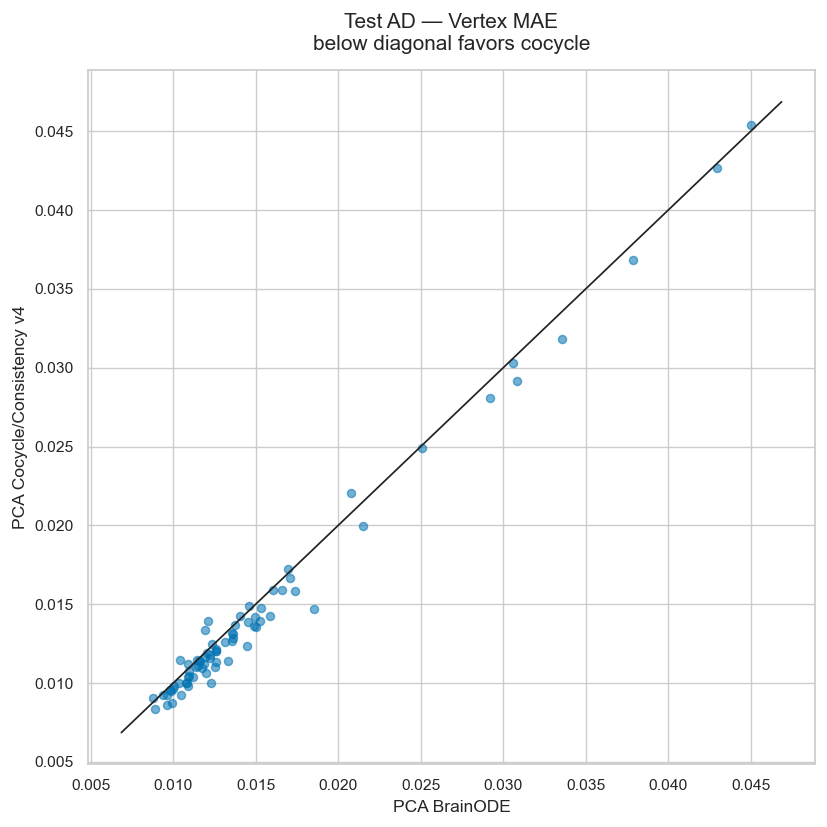

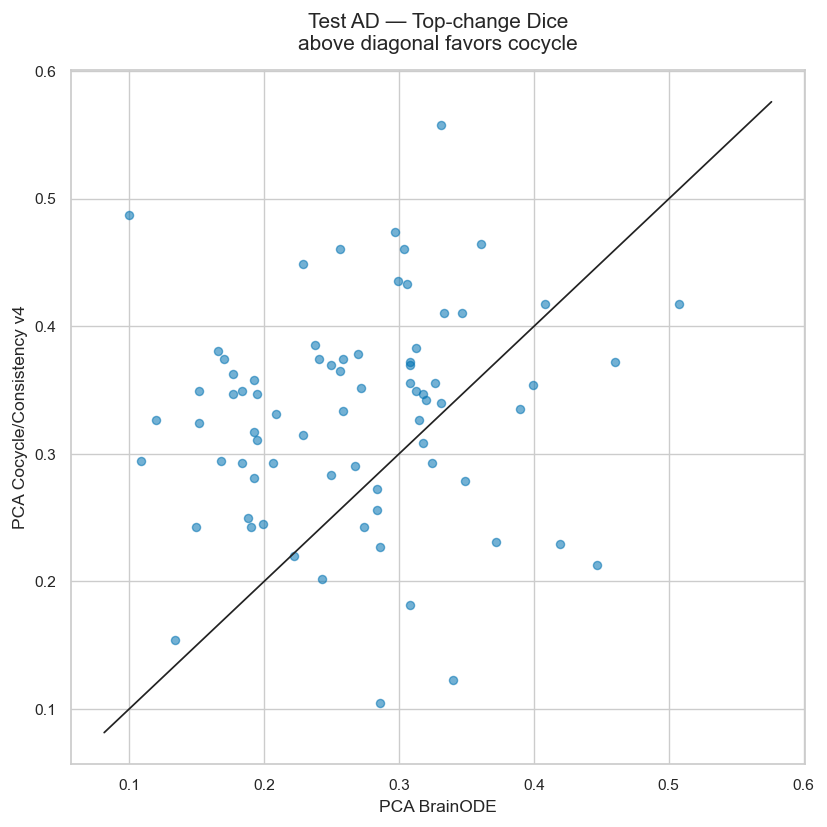

In [8]:
def plot_paired_scatter(metric: str, diagnosis: str = 'AD', split: str = 'test') -> None:
    label, lower_is_better = METRIC_SPECS[metric]
    data = tables['paired'][(tables['paired']['split'] == split) & (tables['paired']['diagnosis'] == diagnosis) & (tables['paired']['metric'] == metric)]
    values = data[['brainode_value', 'cocycle_value']].to_numpy(float)
    low, high = float(np.nanmin(values)), float(np.nanmax(values))
    pad = 0.04 * (high - low + 1e-12)
    fig, ax = plt.subplots(figsize=(6.5, 6.5), constrained_layout=True)
    ax.scatter(data['brainode_value'], data['cocycle_value'], s=22, alpha=0.55, color=MODEL_COLORS['v4'])
    ax.plot([low - pad, high + pad], [low - pad, high + pad], color='#222222', linewidth=1)
    winning_side = 'below diagonal favors cocycle' if lower_is_better else 'above diagonal favors cocycle'
    ax.set_title(f'{split.capitalize()} {diagnosis} — {label}\n{winning_side}', pad=12)
    ax.set_xlabel(MODEL_LABELS['brainode'])
    ax.set_ylabel(MODEL_LABELS['v4'])
    plt.show()

plot_paired_scatter('endpoint_vertex_mae', 'AD', 'test')
plot_paired_scatter('local_normal_top_change_dice', 'AD', 'test')

## Follow-up gap and volume trend

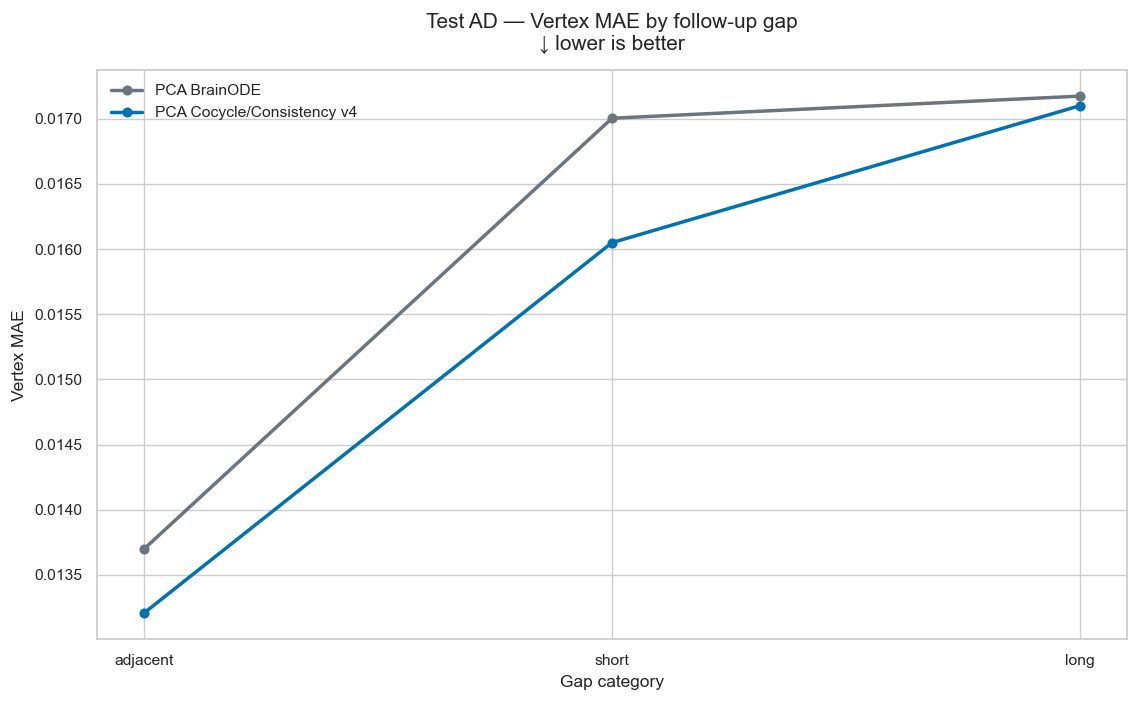

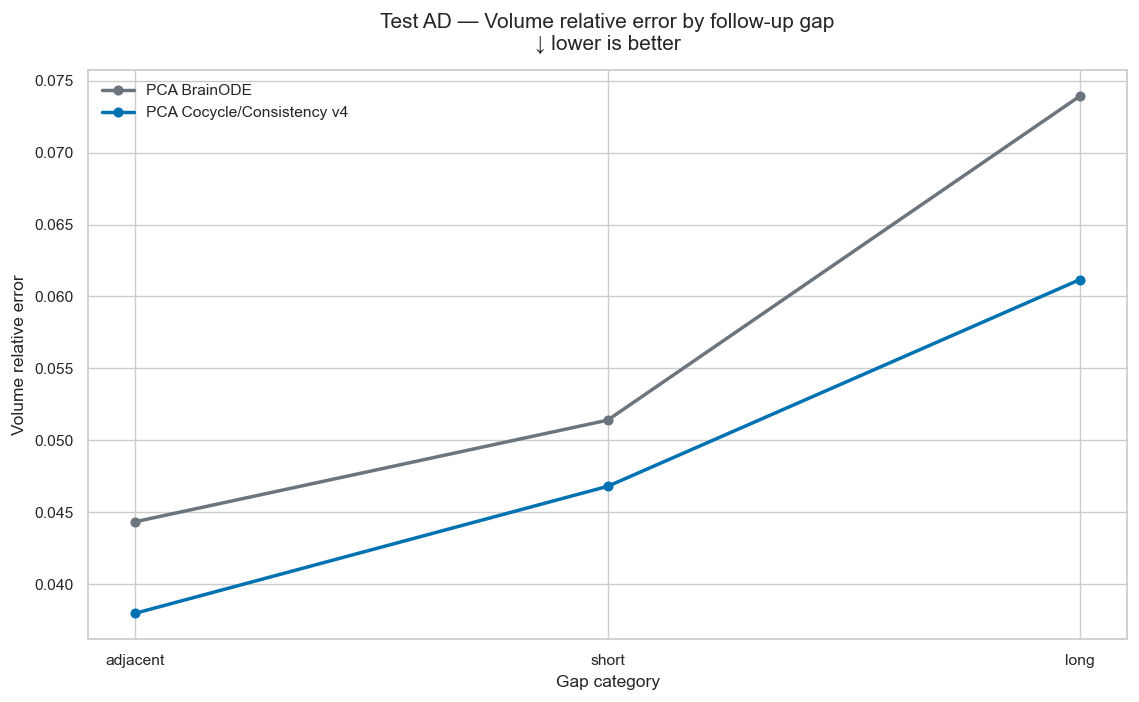

In [9]:
def plot_gap_metric(metric: str, diagnosis: str = 'AD', split: str = 'test') -> None:
    label, lower_is_better = METRIC_SPECS[metric]
    data = tables['gaps'][(tables['gaps']['split'] == split) & (tables['gaps']['diagnosis'] == diagnosis)].copy()
    order = [item for item in ('adjacent', 'short', 'long') if item in set(data['gap_bin'])]
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    for model in ('brainode', 'v4'):
        current = data[data['model'] == model].set_index('gap_bin').reindex(order)
        ax.plot(order, current[metric], marker='o', linewidth=2, color=MODEL_COLORS[model], label=MODEL_LABELS[model])
    arrow = '↓' if lower_is_better else '↑'
    phrase = 'lower is better' if lower_is_better else 'higher is better'
    ax.set_title(f'{split.capitalize()} {diagnosis} — {label} by follow-up gap\n{arrow} {phrase}', pad=12)
    ax.set_xlabel('Gap category')
    ax.set_ylabel(label)
    ax.legend(frameon=False)
    plt.show()

plot_gap_metric('endpoint_vertex_mae', 'AD', 'test')
plot_gap_metric('volume_relative_error', 'AD', 'test')

,split,diagnosis,model,model_label,subjects,observed_slope_mean,predicted_slope_mean,slope_absolute_error_mean,slope_absolute_error_median,slope_pearson,observed_first_last_rate_mean,predicted_first_last_rate_mean,first_last_rate_absolute_error_mean
4,test,AD,brainode,PCA BrainODE,21,-0.037647,-0.013185,0.044268,0.039270,0.015994,-0.037279,-0.013182,0.045205
5,test,AD,v4,PCA Cocycle/Consistency v4,21,-0.037647,-0.044241,0.043243,0.024436,-0.044565,-0.037279,-0.044036,0.044257
6,test,CN,brainode,PCA BrainODE,29,-0.003578,-0.010854,0.027523,0.018191,0.146369,-0.003715,-0.010859,0.027429
7,test,CN,v4,PCA Cocycle/Consistency v4,29,-0.003578,-0.008271,0.026399,0.017243,0.429613,-0.003715,-0.008473,0.026418


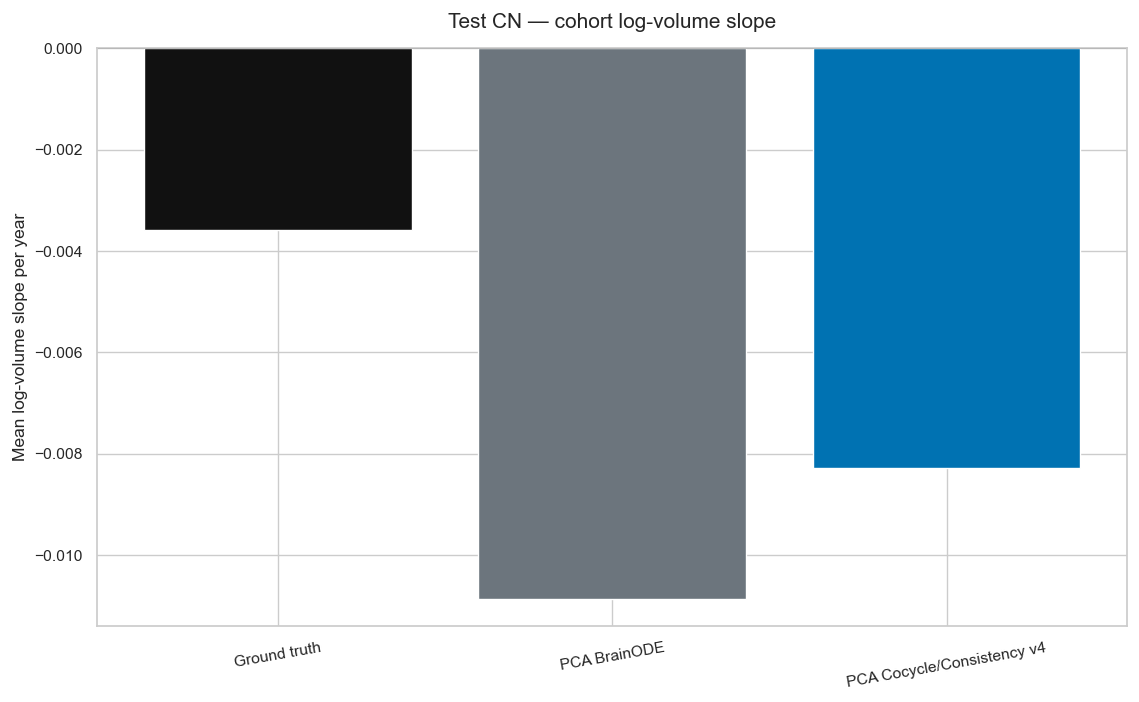

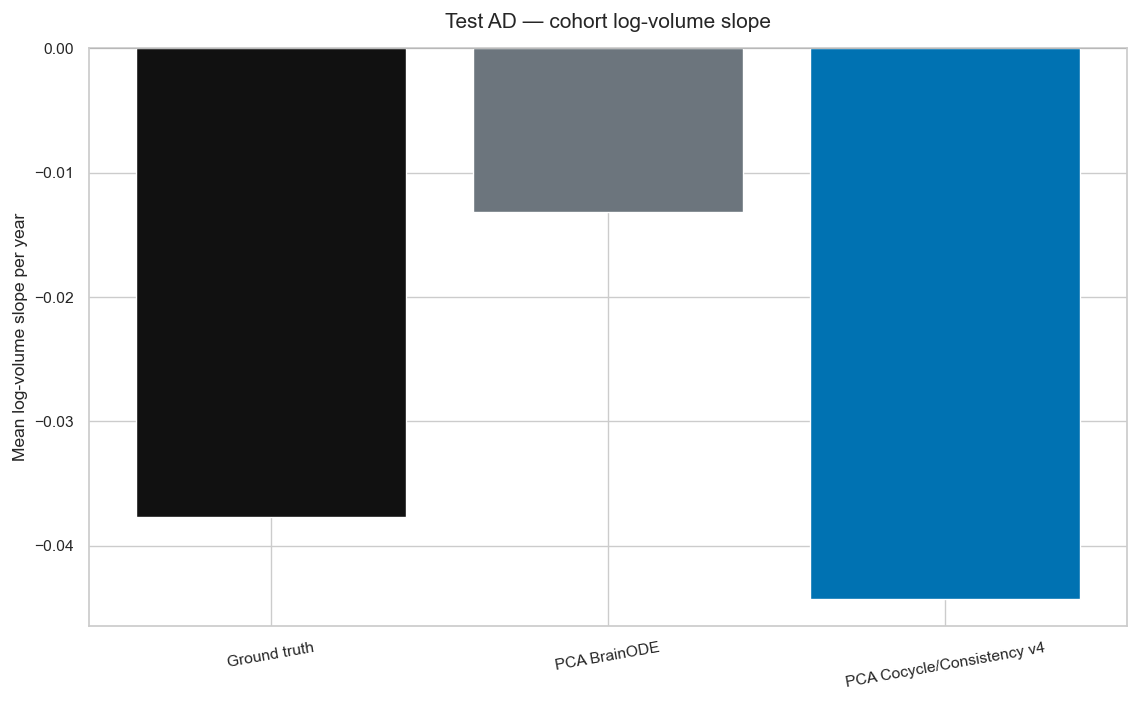

In [10]:
test_trends = tables['trend_summary'][tables['trend_summary']['split'] == 'test'].copy()
display(test_trends.sort_values(['diagnosis', 'model']))

def plot_cohort_slope(diagnosis: str, split: str = 'test') -> None:
    data = tables['trend_summary'][(tables['trend_summary']['split'] == split) & (tables['trend_summary']['diagnosis'] == diagnosis)].copy()
    observed = float(data['observed_slope_mean'].mean())
    labels = ['Ground truth'] + [MODEL_LABELS[model] for model in ('brainode', 'v4')]
    values = [observed] + [float(data.loc[data['model'] == model, 'predicted_slope_mean'].iloc[0]) for model in ('brainode', 'v4')]
    colors = [MODEL_COLORS['GT'], MODEL_COLORS['brainode'], MODEL_COLORS['v4']]
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    ax.bar(labels, values, color=colors)
    ax.axhline(0.0, color='#222222', linewidth=1)
    ax.set_title(f'{split.capitalize()} {diagnosis} — cohort log-volume slope', pad=12)
    ax.set_ylabel('Mean log-volume slope per year')
    ax.tick_params(axis='x', rotation=10)
    plt.show()

plot_cohort_slope('CN')
plot_cohort_slope('AD')

## Saved individual and counterfactual volume trajectories

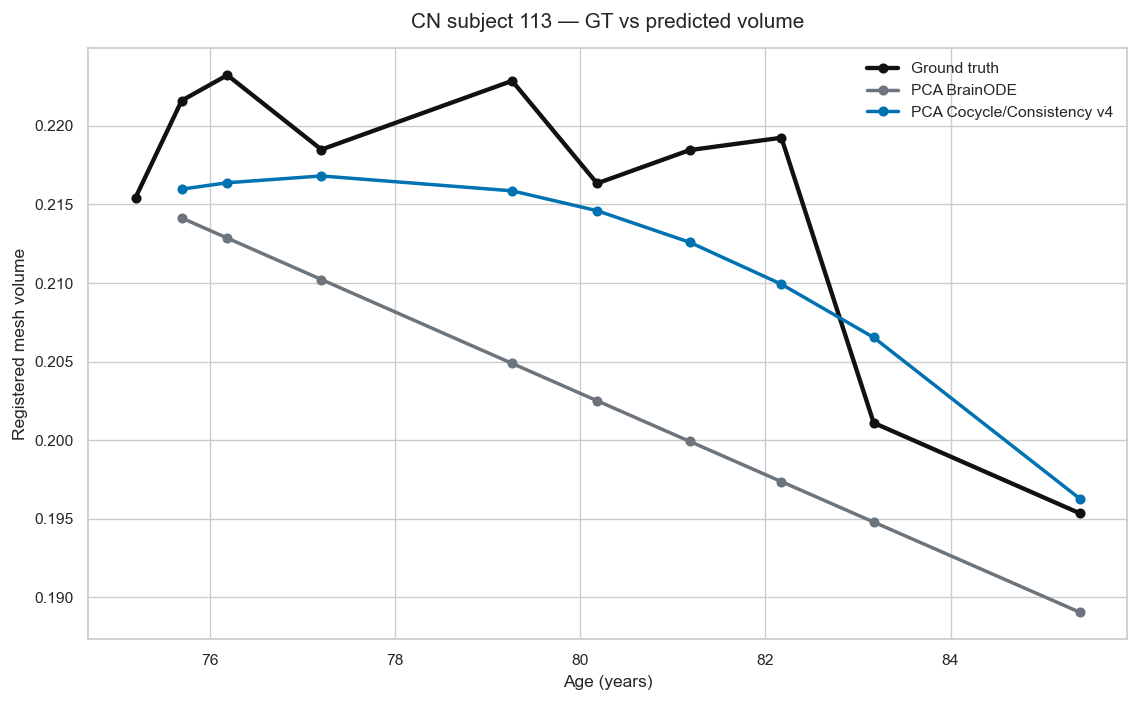

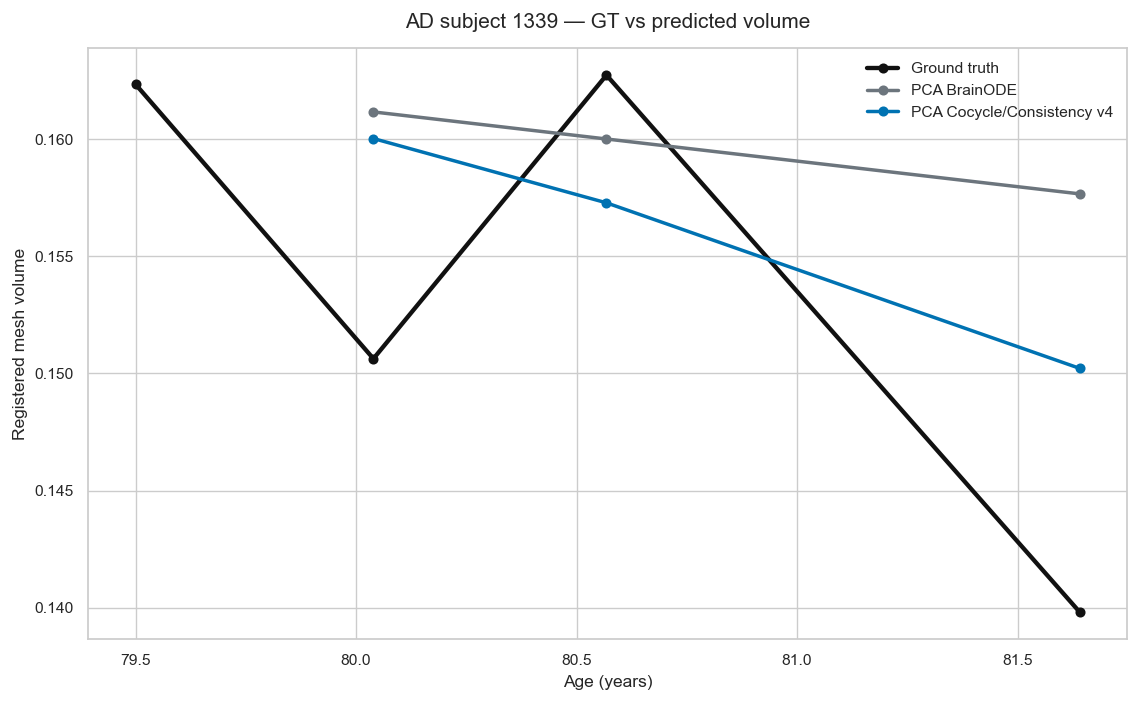

In [11]:
def plot_saved_trajectory(diagnosis: str) -> None:
    data = tables['trajectories'][tables['trajectories']['diagnosis'] == diagnosis].copy()
    subject_id = str(data['subject_id'].iloc[0])
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    gt = data[data['model'] == 'GT'].sort_values('age_years').drop_duplicates(['age_years', 'volume'])
    ax.plot(gt['age_years'], gt['volume'], marker='o', linewidth=2.5, color=MODEL_COLORS['GT'], label='Ground truth')
    for model in ('brainode', 'v4'):
        current = data[data['model'] == model].sort_values('age_years')
        ax.plot(current['age_years'], current['volume'], marker='o', linewidth=2, color=MODEL_COLORS[model], label=MODEL_LABELS[model])
    ax.set_title(f'{diagnosis} subject {subject_id} — GT vs predicted volume', pad=12)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Registered mesh volume')
    ax.legend(frameon=False)
    plt.show()

plot_saved_trajectory('CN')
plot_saved_trajectory('AD')

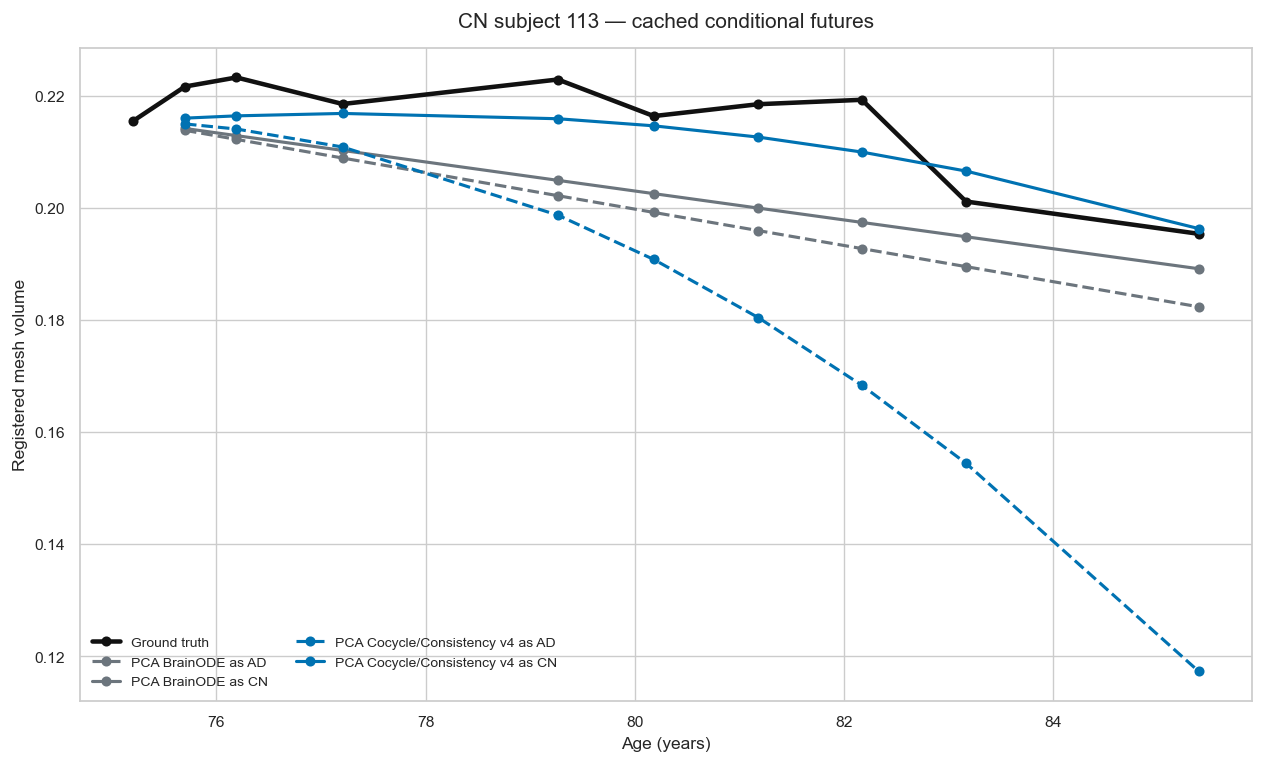

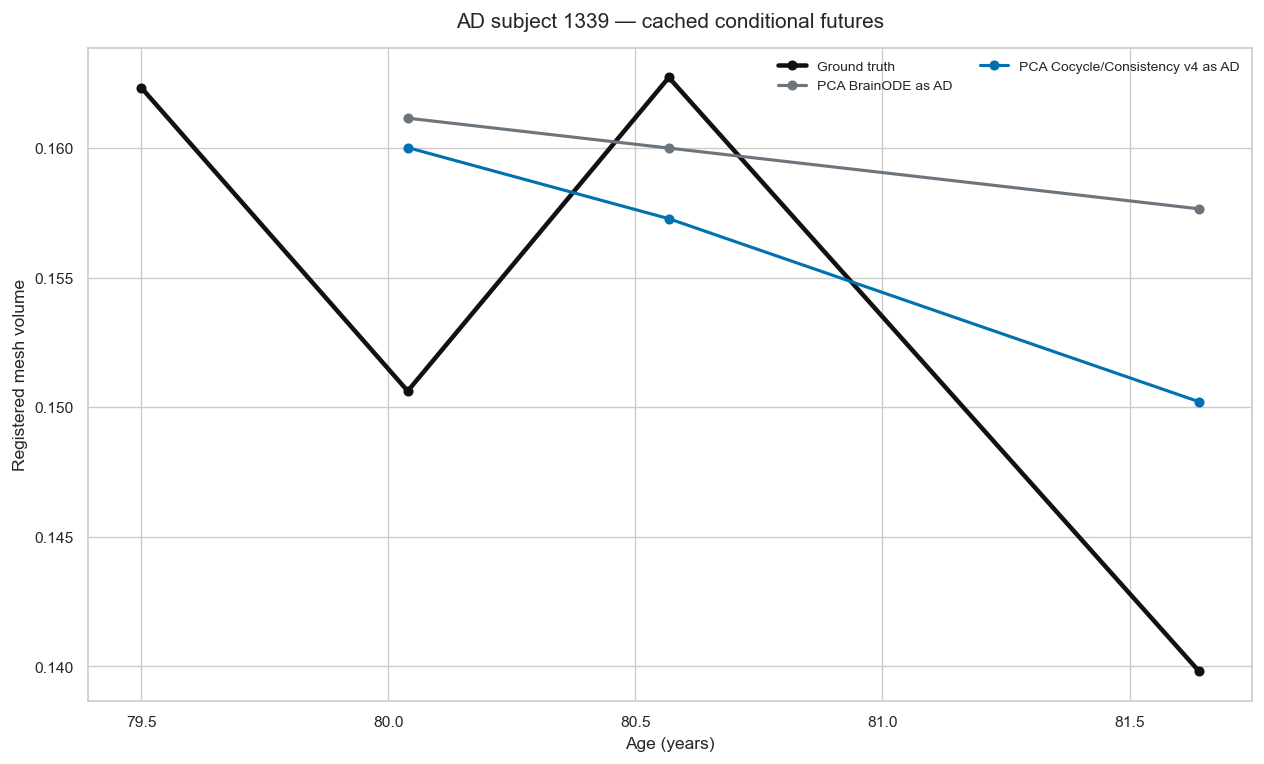

In [12]:
def plot_counterfactual(diagnosis: str) -> None:
    data = tables['counterfactual'][tables['counterfactual']['diagnosis'] == diagnosis].copy()
    subject_id = str(data['subject_id'].iloc[0])
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    gt = data[data['model'] == 'GT'].sort_values('age_years').drop_duplicates(['age_years', 'volume'])
    ax.plot(gt['age_years'], gt['volume'], marker='o', linewidth=2.6, color=MODEL_COLORS['GT'], label='Ground truth')
    for series, current in data[~data['model'].isin(['GT'])].groupby('series'):
        model = str(current['model'].iloc[0])
        style = '--' if str(current['condition'].iloc[0]) == 'AD' and diagnosis == 'CN' else '-'
        ax.plot(current.sort_values('age_years')['age_years'], current.sort_values('age_years')['volume'], marker='o', linestyle=style, linewidth=1.8, color=MODEL_COLORS[model], label=series)
    title = f'{diagnosis} subject {subject_id} — cached conditional futures'
    ax.set_title(title, pad=12)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Registered mesh volume')
    ax.legend(frameon=False, fontsize=8, ncol=2)
    plt.show()

plot_counterfactual('CN')
plot_counterfactual('AD')

## Cached registered meshes and change locations

The following figures load vertex coordinates, topology, endpoint errors, and normal-change rates directly from CSV files. They do not call either model.

In [13]:
if go is None or make_subplots is None:
    raise ImportError('Plotly is required to display the cached meshes')
faces = pd.read_csv(CACHE_DIR / 'meshes/template_faces.csv')
face_i = faces['vertex_0'].to_numpy(int)
face_j = faces['vertex_1'].to_numpy(int)
face_k = faces['vertex_2'].to_numpy(int)

def add_mesh(fig, frame, columns, row, col, *, color=None, intensity=None, colorscale='Viridis', cmin=None, cmax=None, showscale=False):
    xcol, ycol, zcol = columns
    kwargs = dict(
        x=frame[xcol], y=frame[ycol], z=frame[zcol], i=face_i, j=face_j, k=face_k,
        opacity=1.0, flatshading=False, showscale=showscale, hoverinfo='skip',
    )
    if intensity is None:
        kwargs['color'] = color or '#D9D9D9'
    else:
        kwargs.update(intensity=frame[intensity], colorscale=colorscale, cmin=cmin, cmax=cmax)
    fig.add_trace(go.Mesh3d(**kwargs), row=row, col=col)

def finish_mesh_layout(fig, title: str, height: int) -> go.Figure:
    fig.update_scenes(aspectmode='data', xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
    fig.update_layout(title=title, title_font_size=13, font_size=10, height=height, margin=dict(l=5, r=5, t=70, b=5))
    return fig

def selected_progression_figure(diagnosis: str) -> go.Figure:
    frame = pd.read_csv(CACHE_DIR / f'meshes/selected_{diagnosis.lower()}_vertices.csv')
    cmax = float(np.nanpercentile(np.concatenate([frame['brainode_endpoint_error'], frame['cocycle_endpoint_error']]), 98))
    fig = make_subplots(rows=2, cols=2, specs=[[{'type': 'scene'}, {'type': 'scene'}], [{'type': 'scene'}, {'type': 'scene'}]], subplot_titles=['Source', 'GT future', 'BrainODE endpoint error', 'Cocycle endpoint error'])
    add_mesh(fig, frame, ('source_x', 'source_y', 'source_z'), 1, 1, color='#D9D9D9')
    add_mesh(fig, frame, ('gt_x', 'gt_y', 'gt_z'), 1, 2, color='#BDBDBD')
    add_mesh(fig, frame, ('brainode_x', 'brainode_y', 'brainode_z'), 2, 1, intensity='brainode_endpoint_error', colorscale='Inferno', cmin=0.0, cmax=cmax)
    add_mesh(fig, frame, ('cocycle_x', 'cocycle_y', 'cocycle_z'), 2, 2, intensity='cocycle_endpoint_error', colorscale='Inferno', cmin=0.0, cmax=cmax, showscale=True)
    return finish_mesh_layout(fig, f'{diagnosis} selected subject — registered shape progression', 820)

def selected_change_figure(diagnosis: str) -> go.Figure:
    frame = pd.read_csv(CACHE_DIR / f'meshes/selected_{diagnosis.lower()}_vertices.csv')
    change_columns = ['gt_normal_change_rate', 'brainode_normal_change_rate', 'cocycle_normal_change_rate']
    limit = float(np.nanpercentile(np.abs(frame[change_columns].to_numpy()), 98))
    fig = make_subplots(rows=1, cols=3, specs=[[{'type': 'scene'}] * 3], subplot_titles=['GT local change', 'BrainODE local change', 'Cocycle local change'])
    for col, intensity in enumerate(change_columns, start=1):
        add_mesh(fig, frame, ('source_x', 'source_y', 'source_z'), 1, col, intensity=intensity, colorscale='RdBu', cmin=-limit, cmax=limit, showscale=(col == 3))
    return finish_mesh_layout(fig, f'{diagnosis} selected subject — annualized normal change', 470)

display(tables['selected_mesh_metrics'].sort_values(['diagnosis', 'model']))

,split,diagnosis,subject_id,source_visit_order,target_visit_order,gap_years,model,model_label,vertex_error_mean,normal_change_mae,normal_change_pearson,hotspot_dice,v4_speed
2,test,AD,1339,0,3,2.140999,brainode,PCA BrainODE,0.029741,0.009072,0.293705,0.326531,NaN
3,test,AD,1339,0,3,2.140999,v4,PCA Cocycle/Consistency v4,0.027803,0.008005,0.420450,0.356009,2.919345
0,test,CN,113,0,9,10.195763,brainode,PCA BrainODE,0.031009,0.001990,0.092661,0.136054,NaN
1,test,CN,113,0,9,10.195763,v4,PCA Cocycle/Consistency v4,0.036425,0.002294,0.047812,0.335601,1.000000


In [14]:
selected_progression_figure('CN')

In [15]:
selected_change_figure('CN')

In [16]:
selected_progression_figure('AD')

In [17]:
selected_change_figure('AD')

## Subject-balanced diagnosis-level hotspots

Each subject is averaged first, then subjects are averaged. This prevents participants with more scan pairs from dominating the CN or AD change map.

In [18]:
display(tables['group_hotspot_metrics'].sort_values(['diagnosis', 'model']))

def group_change_figure(diagnosis: str):
    frame = pd.read_csv(CACHE_DIR / f'meshes/group_{diagnosis.lower()}_change_maps.csv')
    if frame.empty:
        return Markdown(f'Group maps for {diagnosis} were skipped. Rebuild the cache without `--skip-group-maps`.')
    change_columns = ['gt_normal_change_rate', 'brainode_normal_change_rate', 'cocycle_normal_change_rate']
    limit = float(np.nanpercentile(np.abs(frame[change_columns].to_numpy()), 98))
    fig = make_subplots(rows=1, cols=3, specs=[[{'type': 'scene'}] * 3], subplot_titles=['GT group change', 'BrainODE group change', 'Cocycle group change'])
    for col, intensity in enumerate(change_columns, start=1):
        add_mesh(fig, frame, ('template_x', 'template_y', 'template_z'), 1, col, intensity=intensity, colorscale='RdBu', cmin=-limit, cmax=limit, showscale=(col == 3))
    return finish_mesh_layout(fig, f'{diagnosis} — subject-balanced location of longitudinal change', 470)

,diagnosis,model,model_label,pairs,subjects,aggregation,normal_change_mae,normal_change_pearson,hotspot_dice,top_fraction
2,AD,brainode,PCA BrainODE,730,205,"mean within subject, then mean across subjects",0.003154,0.719420,0.539683,0.2
3,AD,v4,PCA Cocycle/Consistency v4,730,205,"mean within subject, then mean across subjects",0.001755,0.857732,0.693878,0.2
0,CN,brainode,PCA BrainODE,3955,318,"mean within subject, then mean across subjects",0.000729,0.766381,0.616780,0.2
1,CN,v4,PCA Cocycle/Consistency v4,3955,318,"mean within subject, then mean across subjects",0.000750,0.748349,0.571429,0.2


In [19]:
group_change_figure('CN')

In [20]:
group_change_figure('AD')

## Interpretation checklist

- Use the **test** split for the primary claim against PCA BrainODE.
- Treat `split = all` as descriptive because it is dominated by the training cohort.
- Positive `delta_favoring_cocycle` always means cocycle is better.
- Report Dice/Pearson as absolute gains, not relative percentages.
- Separate pairwise volume accuracy from subject-level trajectory agreement.
- Report both selected-subject and subject-balanced group hotspot results; the selected mesh is qualitative evidence, while group metrics support the quantitative claim.